In [88]:
import pandas as pd
import numpy as np
import os
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import  plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import het_arch
import matplotlib.pyplot as plt
from datetime import datetime as dt
import pytz

In [89]:
df = pd.read_excel('pib_preco_mercado.xls', engine='xlrd')
df.head()

,Data,PIB
0,2010 T1,886397.39
1,2010 T2,944145.04
2,2010 T3,997934.74
3,2010 T4,1057369.83
4,2011 T1,1016530.65


In [90]:
pd.options.display.float_format = '{:.2f}'.format
df.head()

,Data,PIB
0,2010 T1,886397.39
1,2010 T2,944145.04
2,2010 T3,997934.74
3,2010 T4,1057369.83
4,2011 T1,1016530.65


In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Data    64 non-null     str    
 1   PIB     64 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.6 KB


In [92]:
df["Data"] = df["Data"].astype("str")
df["Data"] = df["Data"].str.replace(r"(\d{4})\s*T(\d)", r"\1Q\2", regex=True)
df["Data"] = pd.PeriodIndex(df["Data"], freq="Q")
df = df.set_index("Data")
df

,PIB
Data,
2010Q1,886397.39
2010Q2,944145.04
2010Q3,997934.74
2010Q4,1057369.83
2011Q1,1016530.65
...,...
2024Q4,3063723.26
2025Q1,3024722.91
2025Q2,3200345.02


<Axes: xlabel='Data'>

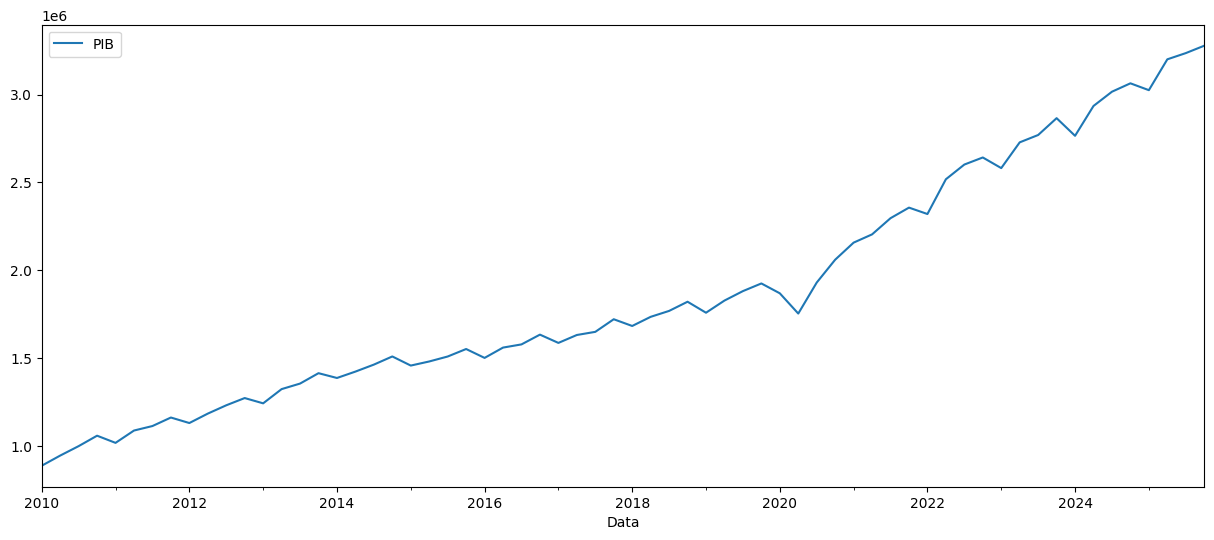

In [93]:
df.plot(figsize=(15,6))

A série tem uma tendência. Ir-se-á, agora, estudar o correlograma.

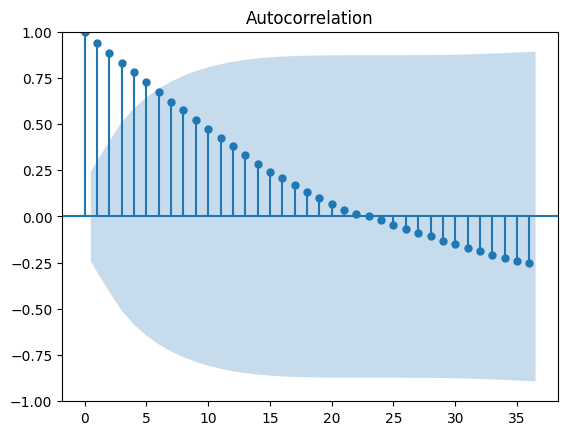

In [94]:
plot_acf(df['PIB'], lags=36)
plt.show()

A série do PIB em nível parece não estacionária e possivelmente possui uma raiz unitária. Testa-se, a seguir, a presença de raiz unitária através dos testes ADF e KPSS.

In [95]:
resultado = adfuller(df['PIB'].dropna())
print('Estatística ADF:', resultado[0])
print('p-value:', resultado[1])
print('Número de lags usados:', resultado[2])
print('Número de observações:', resultado [3])

print('\nValores Críticos:')
for chave, valor in resultado[4].items():
    print(f'{chave}: {valor}')

Estatística ADF: 1.6642675561231024
p-value: 0.9980381293576872
Número de lags usados: 4
Número de observações: 59

Valores Críticos:
1%: -3.5463945337644063
5%: -2.911939409384601
10%: -2.5936515282964665


O Teste de Dickey-Fuller (ADF) reforça que a série é não estacionária, tal qual foi visualizado através dos correlogramas. Isso se justifica porque o valor do teste ADF é 1,664267, que é maior que os valores críticos de 1%, 5% e 10%. Na verdade, seu p-value é de 0,9980 (99,80%).

Vamos fazer o teste KPSS.

O teste ADF pergunta se a série tem raiz unitária. O KPSS pergunta se a série é estacionária.

In [96]:
resultado2 = kpss(df['PIB'].dropna(), regression= 'c')

print("Estatística KPSS:", resultado2[0])
print('p-value:', resultado2[1])
print('Lags usados:', resultado2[2])
print('\nValores críticos:')
for chave, valor in resultado2[3].items():
    print(f'{chave}: {valor}')

Estatística KPSS: 1.1157946821539035
p-value: 0.01
Lags usados: 5

Valores críticos:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


C:\Users\marci\AppData\Local\Temp\ipykernel_7556\1060829343.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  resultado2 = kpss(df['PIB'].dropna(), regression= 'c')


Como
H0: a série é estacionária
H1: a série não é estacionária

P-value 0.01, rejeitamos a Hipótese nula e aceitamos a hipótese alternativa. Logo, a série não é estacionária.

Vamos diferenciá-la, então.

In [97]:
serie_diff = df['PIB'].diff().dropna()
serie_diff

Data
2010Q2    57747.65
2010Q3    53789.70
2010Q4    59435.09
2011Q1   -40839.18
2011Q2    70181.58
            ...   
2024Q4    47787.34
2025Q1   -39000.35
2025Q2   175622.10
2025Q3    35362.52
2025Q4    42082.61
Freq: Q-DEC, Name: PIB, Length: 63, dtype: float64

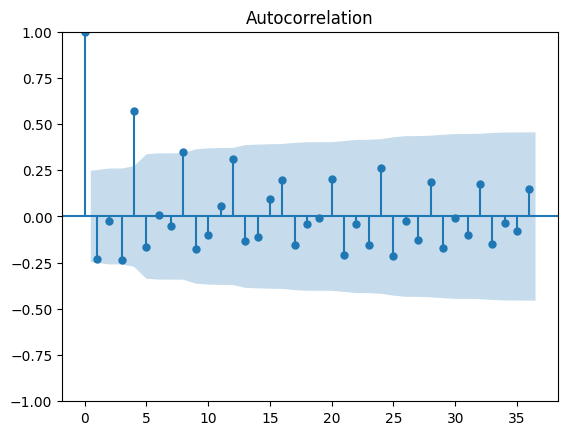

In [98]:
plot_acf(serie_diff, lags=36)
plt.show()

Os dados sugerem uma sazonalidade a cada 4 períodos (observa-se pelos picos mais elevados a cada 4 períodos). Como os dados são trimestrais, isso sugere que a sazonalidade seja anual.

Faz-se a seguir o correlograma parcial.

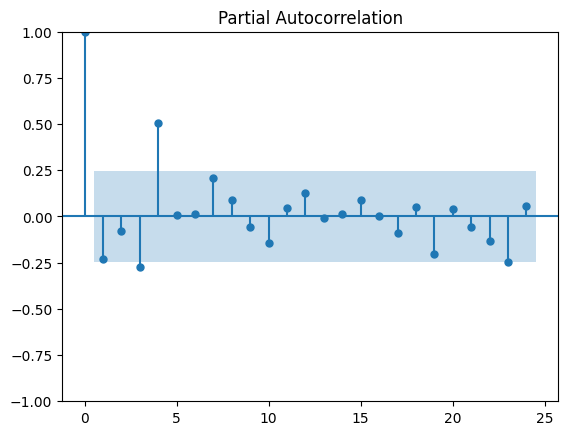

In [99]:
plot_pacf(serie_diff, lags=24)
plt.show()

Pelo correlograma e pelo correlograma parcial há indícios de sazonalidade anual (a cada 4 trimestres, no caso). Mas antes, precisa-se confirmar se os dados do PIB em primeira diferença são estacionários. Mais uma vez, realiza-se os testes ADF e KPSS, agora, na série diferençada uma vez.

In [100]:
resultado3 = adfuller(serie_diff)
print('Estatística ADF:', resultado3[0])
print('p-value:', resultado3[1])
print('Número de lags usados:', resultado3[2])
print('Número de observações:', resultado3 [3])

print('\nValores Críticos:')
for chave, valor in resultado3[4].items():
    print(f'{chave}: {valor}')

Estatística ADF: -2.5505634564972945
p-value: 0.10365119939800499
Número de lags usados: 3
Número de observações: 59

Valores Críticos:
1%: -3.5463945337644063
5%: -2.911939409384601
10%: -2.5936515282964665


Mais uma vez, a série não é estacionária a 10%, pelo teste ADF. Talvez, a causa seja a sazonalidade a cada 4 trimestres. Antes de diferenciar uma segunda vez ou de calcular o teste KPSS, faz-se o teste ADF da diferença sazonal.

In [101]:
serie_diff_sazonal = serie_diff.diff(4).dropna()

In [102]:
resultado4 = adfuller(serie_diff_sazonal)
print('Estatística ADF:', resultado4[0])
print('p-value:', resultado4[1])
print('Número de lags usados:', resultado4[2])
print('Número de observações:', resultado4 [3])

print('\nValores Críticos:')
for chave, valor in resultado4[4].items():
    print(f'{chave}: {valor}')

Estatística ADF: -6.37392218086465
p-value: 2.3087162018537328e-08
Número de lags usados: 3
Número de observações: 55

Valores Críticos:
1%: -3.5552728880540942
5%: -2.9157312396694217
10%: -2.5956695041322315


Agora, sim, a série em primeira diferença do PIB passa no teste ADF de estacionariedade dos dados. Agora, faz-se o Teste KPSS para a série difernçada.

In [103]:
resultado5 = kpss(serie_diff_sazonal, regression= 'c')

print("Estatística KPSS:", resultado5[0])
print('p-value:', resultado5[1])
print('Lags usados:', resultado5[2])
print('\nValores críticos:')
for chave, valor in resultado5[3].items():
    print(f'{chave}: {valor}')

Estatística KPSS: 0.03847124840250666
p-value: 0.1
Lags usados: 1

Valores críticos:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


C:\Users\marci\AppData\Local\Temp\ipykernel_7556\253143405.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  resultado5 = kpss(serie_diff_sazonal, regression= 'c')


O teste KPSS aceita a hipótese nula de não haver presença de raiz unitária. Por tanto, a série do PIB diferençada uma vez e com ajuste da sazonalidade é estacionária.

Plota-se o correlograma da serie_diff_sazonal

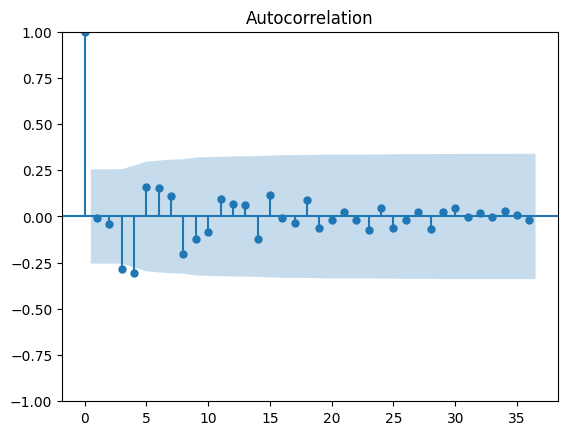

In [104]:
plot_acf(serie_diff_sazonal, lags=36)
plt.show()

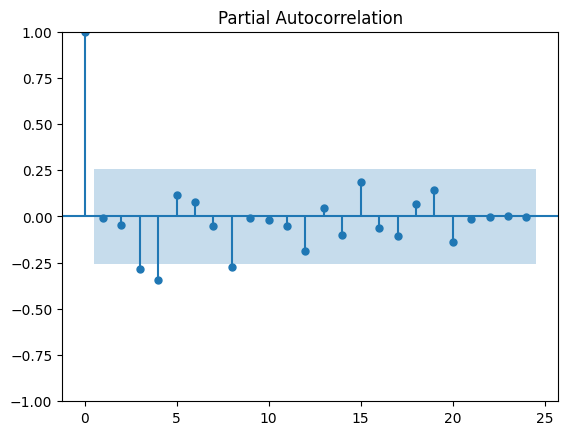

In [105]:
plot_pacf(serie_diff_sazonal, lags=24)
plt.show()

O lag 4, fora da banda, no gráfico ACF indica MA sazonal. Um modelo sugestivo é SARIMA(0,1,1)(0,1,1,4).

In [106]:
df['log_PIB'] = np.log(df['PIB'])

In [107]:
modelo = SARIMAX(df['log_PIB'], order=(0,1,1), seasonal_order=(0,1,1,4), enforce_stationarity=False, enforce_invertibility=False)

result_model = modelo.fit()
print(result_model.summary())

                                     SARIMAX Results                                     
Dep. Variable:                           log_PIB   No. Observations:                   64
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 4)   Log Likelihood                 118.481
Date:                           Thu, 16 Apr 2026   AIC                           -230.962
Time:                                   14:05:35   BIC                           -225.051
Sample:                               03-31-2010   HQIC                          -228.689
                                    - 12-31-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0962      0.089     -1.083      0.279      -0.270       0.078
ma.S.L4       -1.0017      8.790     -0.114

Como MA.L1 não é significativa, será retirada do modelo.

In [108]:
modelo2 = SARIMAX(df['log_PIB'], order=(0,1,0), seasonal_order=(0,1,1,4), enforce_stationarity=False, enforce_invertibility=False)

result_model2 = modelo2.fit()
print(result_model2.summary())

                                      SARIMAX Results                                      
Dep. Variable:                             log_PIB   No. Observations:                   64
Model:             SARIMAX(0, 1, 0)x(0, 1, [1], 4)   Log Likelihood                 120.529
Date:                             Thu, 16 Apr 2026   AIC                           -237.058
Time:                                     14:05:35   BIC                           -233.080
Sample:                                 03-31-2010   HQIC                          -235.524
                                      - 12-31-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.S.L4       -0.9019      0.120     -7.514      0.000      -1.137      -0.667
sigma2         0.0006   6.6

Houve uma melhora nos critérios de Akayke (AIC) e de Schwartz (BIC). Não há autocorrelação nos resíduos pelo teste de Ljung-Box, nem heterocedasticidade dos resíduos. O Teste de Jarque-Bera rejeita a hipótese de normalidade dos resíduos. Como os resíduos são simétricos e há problema na curtose, a não normalidade da distribuição dos mesmos advém da curtose (caudas pesadas, com muitos outliers significativos, provavelmente). O que se justifica devido a choques econômicos, como a pandemia, que afetam o PIB. Testa-se, a seguir, um novo modelo com a presença de uma dummy para a pandemia.

In [109]:
df['dummy_2020'] = (df.index.year == 2020).astype(int)

In [110]:
modelo3 = SARIMAX(df['log_PIB'], exog=df[ 'dummy_2020'], order=(0,1,0), seasonal_order=(0,1,1,4), enforce_stationarity=False, enforce_invertibility=False)

result_model3 = modelo3.fit()
print(result_model3.summary())

                                      SARIMAX Results                                      
Dep. Variable:                             log_PIB   No. Observations:                   64
Model:             SARIMAX(0, 1, 0)x(0, 1, [1], 4)   Log Likelihood                 123.227
Date:                             Thu, 16 Apr 2026   AIC                           -240.454
Time:                                     14:05:35   BIC                           -234.487
Sample:                                 03-31-2010   HQIC                          -238.153
                                      - 12-31-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
dummy_2020    -0.0374      0.011     -3.279      0.001      -0.060      -0.015
ma.S.L4       -0.7746      

Houve uma leve piora no teste da heterocedasticidade. Porém, o mesmo continua sendo significativo ao nível de 5%. Os critérios AIC e BIC melhoraram (diminuíram). A presença da dummy_2020 se mostrou estatisticamente significativa. Apenas a curtose continua mostrando problemas.

Próximo passo é estimar os próximos 4 trimestres, para o ano completo de 2026.

In [111]:
exog_futuro = pd.DataFrame({'dummy_2020':[0, 0, 0, 0]})

forecast_log = result_model3.forecast(steps=4, exog=exog_futuro)
forecast_nivel = np.exp(forecast_log)

forecast_nivel


2026Q1   3215917.91
2026Q2   3363462.95
2026Q3   3455723.99
2026Q4   3543861.33
Freq: Q-DEC, Name: predicted_mean, dtype: float64

Agora, monta-se o gráfico do PIB, com a previsão para o ano de 2026 em vermelho.

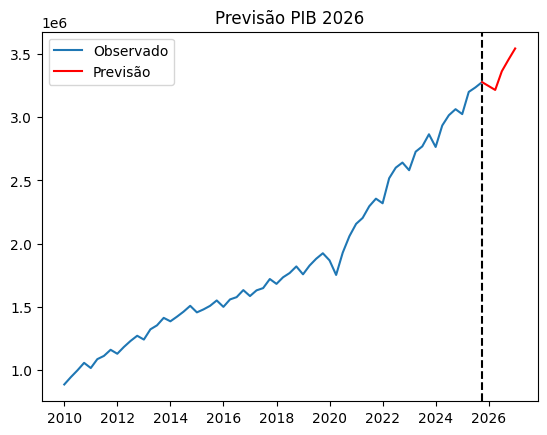

In [120]:
if isinstance(df.index, pd.PeriodIndex):
    df.index = df.index.to_timestamp

hist = df['PIB'].copy()
prev = forecast_nivel.copy()

serie_completa = pd.concat([hist.iloc[[-1]], prev])

plt.Figure(figsize=(15, 6))
plt.plot(hist.index, hist.values, label='Observado')
plt.plot(serie_completa.index, serie_completa.values, label="Previsão", color='red')

plt.axvline(x=hist.index[-1], color='black', linestyle='--')

plt.legend()
plt.title('Previsão PIB 2026')
plt.show()

Agora, calcula-se o intervalo de confiança das previsões trimestrais.

In [121]:
forecast_log= result_model3.get_forecast(steps=4, exog=exog_futuro)
conf_int_log = forecast_log.conf_int()

conf_int_nivel = np.exp(conf_int_log)
conf_int_nivel.columns=['lower', 'upper']
conf_int_nivel

,lower,upper
2026Q1,3066108.40,3373047.09
2026Q2,3144041.72,3598197.47
2026Q3,3181678.35,3753373.84
2026Q4,3221387.66,3898615.89


Próximo passo é exportar as projeções do PIB trimestrais de 2026 e os seus respectivos intervalos de confiança para uma planilha no excel.

In [122]:
forecast_nivel.to_excel('previsao_PIB_2026.xlsx')

In [123]:
conf_int_nivel.to_excel('interv_confianca_PIB.xlsx')

In [124]:
exog_futuro = pd.DataFrame({'dummy_2020':[0, 1, 0, 0]})

forecast_log = result_model3.forecast(steps=4, exog=exog_futuro)
forecast_nivel = np.exp(forecast_log)

forecast_nivel


2026Q1   3215917.91
2026Q2   3239949.62
2026Q3   3455723.99
2026Q4   3543861.33
Freq: Q-DEC, Name: predicted_mean, dtype: float64

In [ ]:
exog_futuro = pd.DataFrame({'dummy_2020':[0, 1, 1, 0]})

forecast_log = result_model3.forecast(steps=4, exog=exog_futuro)
forecast_nivel = np.exp(forecast_log)

forecast_nivel


2026Q1   3215917.91
2026Q2   3239949.62
2026Q3   3328822.65
2026Q4   3478183.77
Freq: Q-DEC, Name: predicted_mean, dtype: float64

In [126]:
exog_futuro = pd.DataFrame({'dummy_2020':[0, 1, 1, 1]})

forecast_log = result_model3.forecast(steps=4, exog=exog_futuro)
forecast_nivel = np.exp(forecast_log)

forecast_nivel


2026Q1   3215917.91
2026Q2   3239949.62
2026Q3   3328822.65
2026Q4   3413723.41
Freq: Q-DEC, Name: predicted_mean, dtype: float64